In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Introduction

Monetary policy is often analyzed using the Taylor rule, which describes how policy rates respond to inflation [1]. Instead of estimating a full reaction function, this project examines whether a simpler statistical relationship between lagged policy rates and inflation can be identified using linear regression. The objective is to explore how the association between monetary policy and inflation varies across different time lags, and whether simple models can capture patterns consistent with monetary transmission mechanisms. The analysis focuses interpretation rather than prediction.

<br>

[1]. https://www.riksbank.se/sv/press-och-publicerat/nyheter-och-pressmeddelanden/nyheter/2017/dagens-penningpolitik-ar-i-linje-med-taylor-regeln/

#1. Retrieving and Cleaning
---
Collect the data from SCB using an API.

In [2]:
import requests
import pandas as pd

# Både url och payload finns tillgängligt på SCB (längst ner, under tabellen):
# https://www.statistikdatabasen.scb.se/pxweb/sv/ssd/START__PR__PR0101__PR0101G/KPIF/table/tableViewLayout1/?loadedQueryId=160586&timeType=from&timeValue=1987M01

SCB_url = "https://api.scb.se/OV0104/v1/doris/sv/ssd/START/PR/PR0101/PR0101G/KPIF"

payload = {
    "query": [
        {
            "code": "ContentsCode",
            "selection": {
                "filter": "item",
                "values": ["PR0101F1"]  # KPIF
            }}],
    "response": {
        "format": "json" }
}

# API request
response = requests.post(SCB_url, json=payload)
api = response.json()


Converting fetched data to a panda dataframe.

In [3]:
''' Understand the format of the API '''
#print(api)
#print(type(api))
inflation_data = api['data'][12::] #[12::] för att de första 12 elementen hade inflationsvärdet [..]. Med hjälp av list slicing tar jag enkelt bort dem.
#print(inflation_data)
#print(type(inflation_data[0]))
#print(inflation_data[12])

''' Create a dataframe '''
inflation_df = pd.DataFrame(inflation_data)
#print(inflation_df)
inflation_df.rename(columns={'key': 'date', 'values': 'inflation'}, inplace=True)

''' Some adjustments '''
inflation_df['date'] = inflation_df['date'].str[0]
inflation_df['inflation'] = inflation_df['inflation'].str[0]

''' Converting columns to the correct datatype '''
inflation_df['date'] = pd.to_datetime(inflation_df['date'], format= '%YM%m') # Före har jag format [yyyy'M'mm], ex. [1988M01]
inflation_df['inflation'] = inflation_df['inflation'].astype(float) #Inflationsvärdena från string till float
inflation_df = inflation_df.reset_index(drop=True) #Ta bort index, behövs ej

print(inflation_df)



          date  inflation
0   1988-01-01        4.5
1   1988-02-01        4.9
2   1988-03-01        5.2
3   1988-04-01        5.9
4   1988-05-01        6.0
..         ...        ...
450 2025-07-01        3.0
451 2025-08-01        3.2
452 2025-09-01        3.1
453 2025-10-01        3.1
454 2025-11-01        2.3

[455 rows x 2 columns]


The Policy Rate is instead imported from an excel available at the Swedish Central Bank (Riksbanken) website: <br>
https://www.riksbank.se/sv/statistik/rantor-och-valutakurser/styrranta-in--och-utlaningsranta/

In [4]:
styrranta_df = pd.read_excel('/content/drive/MyDrive/LINC/styrrantan-effektiv.xlsx')
#print(styrranta_df)
#print(type(styrranta_df))
#print(type(styrranta_df['Unnamed: 0']))
styrranta_df['Unnamed: 0'] = pd.to_datetime(styrranta_df['Unnamed: 0'], format= '%Y-%m-%d')
styrranta_df.rename(columns={'Unnamed: 0': 'date', 'Styrräntan per förändring (effektiv)': 'styrränta'}, inplace=True)
print(styrranta_df)


          date  styrränta
0   2006-01-26       1.75
1   2006-03-02       2.00
2   2006-05-03       2.00
3   2006-06-22       2.25
4   2006-09-07       2.50
..         ...        ...
120 2025-06-25       2.00
121 2025-08-27       2.00
122 2025-10-01       1.75
123 2025-11-12       1.75
124 2026-01-07       1.75

[125 rows x 2 columns]


Ensuring timeorder using built-in pandas functions.

In [6]:
inflation_df = inflation_df.sort_values('date')
styrranta_df = styrranta_df.sort_values('date')

One apparent issue with the data is the difference in frequency of updates. Inflation is updated monthly whereas the policy rate is provided closer to every other month (8 updates/yr). However, the policy rate is constant for the entire period in-between updates and an approximation of monthly rates can be made by filling out missing months the with the value of the entire period.

In [7]:
inflation_df['month'] = inflation_df['date'].dt.to_period('M')
styrranta_df['month'] = styrranta_df['date'].dt.to_period('M')
print(inflation_df)
print(styrranta_df)


styrranta_manad = styrranta_df[['month', 'styrränta']]
print(styrranta_manad)

print(inflation_df['month'].is_unique) #if true => no duplicates :)

styrranta_manad = inflation_df[['month']].merge(styrranta_manad, on='month', how='left')
styrranta_manad['styrränta'] = styrranta_manad['styrränta'].ffill()
print(styrranta_manad)




          date  inflation    month
0   1988-01-01        4.5  1988-01
1   1988-02-01        4.9  1988-02
2   1988-03-01        5.2  1988-03
3   1988-04-01        5.9  1988-04
4   1988-05-01        6.0  1988-05
..         ...        ...      ...
450 2025-07-01        3.0  2025-07
451 2025-08-01        3.2  2025-08
452 2025-09-01        3.1  2025-09
453 2025-10-01        3.1  2025-10
454 2025-11-01        2.3  2025-11

[455 rows x 3 columns]
          date  styrränta    month
0   2006-01-26       1.75  2006-01
1   2006-03-02       2.00  2006-03
2   2006-05-03       2.00  2006-05
3   2006-06-22       2.25  2006-06
4   2006-09-07       2.50  2006-09
..         ...        ...      ...
120 2025-06-25       2.00  2025-06
121 2025-08-27       2.00  2025-08
122 2025-10-01       1.75  2025-10
123 2025-11-12       1.75  2025-11
124 2026-01-07       1.75  2026-01

[125 rows x 3 columns]
       month  styrränta
0    2006-01       1.75
1    2006-03       2.00
2    2006-05       2.00
3    2006-06    

Create one large dataframe containing both inflation and policy rate.

In [8]:
total_df = inflation_df.merge(styrranta_manad, on='month', how='inner')
total_df = total_df[['date', 'inflation', 'styrränta']].sort_values('date').reset_index(drop=True)
print(total_df.head(), total_df.tail())

        date  inflation  styrränta
0 1988-01-01        4.5        NaN
1 1988-02-01        4.9        NaN
2 1988-03-01        5.2        NaN
3 1988-04-01        5.9        NaN
4 1988-05-01        6.0        NaN           date  inflation  styrränta
451 2025-07-01        3.0       2.00
452 2025-08-01        3.2       2.00
453 2025-09-01        3.1       2.00
454 2025-10-01        3.1       1.75
455 2025-11-01        2.3       1.75


Adressing limitations in data: The policy rate goes back only to 2006 - why no existing values, NaN, exist for previous updates. The extent of the study is therefor limited to the time period of the policy rate.


In [9]:
total_df = total_df.dropna().reset_index(drop=True)

In [10]:
#240 datapoints with inflation AND policy rate remains
print(total_df.shape, '\n', total_df.head(), '\n' ,total_df.tail())


(240, 3) 
         date  inflation  styrränta
0 2006-01-01        1.2       1.75
1 2006-02-01        1.1       1.75
2 2006-03-01        1.5       2.00
3 2006-04-01        1.8       2.00
4 2006-05-01        1.9       2.00 
           date  inflation  styrränta
235 2025-07-01        3.0       2.00
236 2025-08-01        3.2       2.00
237 2025-09-01        3.1       2.00
238 2025-10-01        3.1       1.75
239 2025-11-01        2.3       1.75


#2. Data Analysis
---

Visual inspection of data. A plot of inflation and policy rate over time, 2006/01-2025/11, as well as a scatterplot of inflation against policy rate.

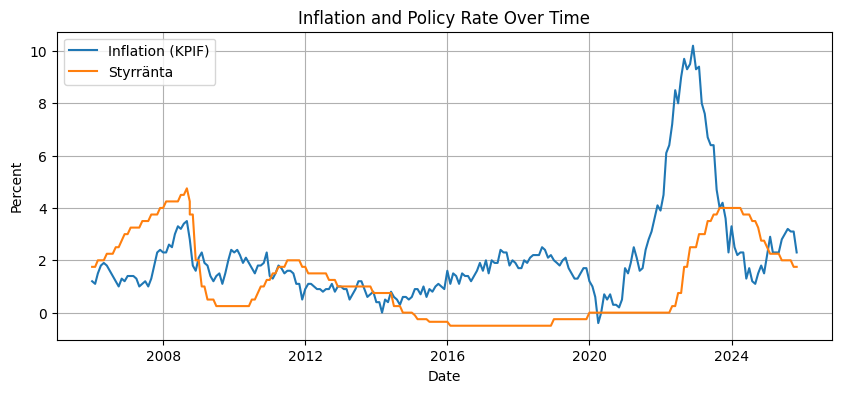

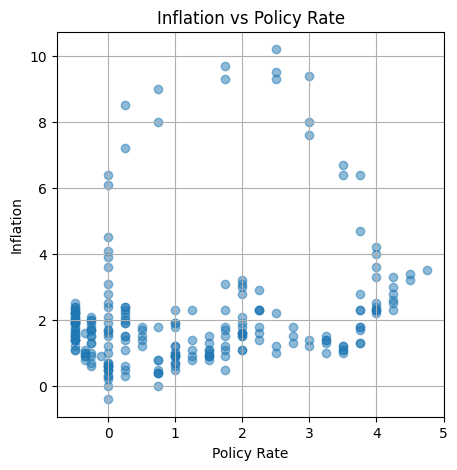

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(total_df['date'], total_df['inflation'], label='Inflation (KPIF)')
plt.plot(total_df['date'], total_df['styrränta'], label='Styrränta')
plt.xlabel('Date')
plt.ylabel('Percent')
plt.title('Inflation and Policy Rate Over Time')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5,5))
plt.scatter(total_df['styrränta'], total_df['inflation'], alpha=0.5)
plt.xlabel('Policy Rate')
plt.ylabel('Inflation')
plt.title('Inflation vs Policy Rate')
plt.grid(True)
plt.show()

The scatter plot illustrates a weak positive correlation upon inspection, which is confirmed by computation below. A relatively low correlation is likely expected since the inflation is affected by many factors besides policy rate, like global prices and market expectations.

In [12]:
corr = total_df[['inflation','styrränta']].corr()
print(corr)


           inflation  styrränta
inflation   1.000000   0.250193
styrränta   0.250193   1.000000


The policy rate is used by the central bank to influence inflation and the overall economy. The effect of the policy rate is delayed, as it takes time for markets to adjust. It typically takes 1-2 years for changes in the policy rate to have an impact [2]. Therefore, we expect the effects of the policy rate to appear with a time lag, and we are primarily interested in examining the correlation at different lags. A higher policy rate is expected to dampen inflation; consequently, we anticipate a negative correlation. <br> <br> [2]. https://www.sparbankentanum.se/privat/tips-och-rad/vad-ar-styrranta.html

In [19]:
for lag in [1, 3, 6, 12, 24, 48]:
    total_df[f'styrränta_lag{lag}'] = total_df['styrränta'].shift(lag)

Notice that the dataset is reduced when lags are made.

In [20]:
df_lag = total_df.dropna().reset_index(drop=True)
print(df_lag.shape)

(192, 9)


In [21]:
print(df_lag)

          date  inflation  styrränta  styrränta_lag1  styrränta_lag3  \
0   2009-12-01        2.4       0.25            0.25            0.25   
1   2010-01-01        2.3       0.25            0.25            0.25   
2   2010-02-01        2.4       0.25            0.25            0.25   
3   2010-03-01        2.2       0.25            0.25            0.25   
4   2010-04-01        1.9       0.25            0.25            0.25   
..         ...        ...        ...             ...             ...   
187 2025-07-01        3.0       2.00            2.00            2.25   
188 2025-08-01        3.2       2.00            2.00            2.25   
189 2025-09-01        3.1       2.00            2.00            2.00   
190 2025-10-01        3.1       1.75            2.00            2.00   
191 2025-11-01        2.3       1.75            1.75            2.00   

     styrränta_lag6  styrränta_lag12  styrränta_lag24  styrränta_lag48  
0              0.50             2.00             4.00         

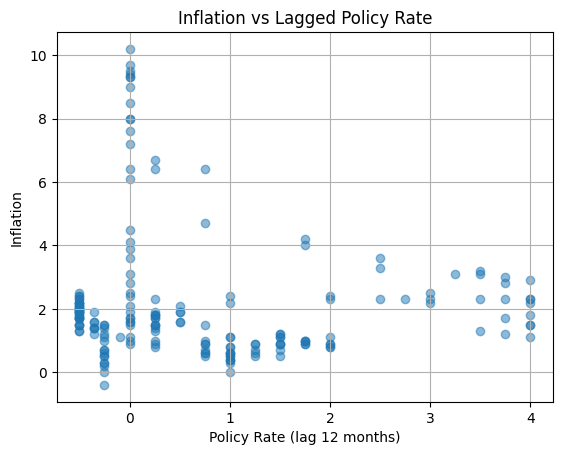

In [26]:
plt.scatter(df_lag['styrränta_lag12'], df_lag['inflation'], alpha=0.5)
plt.xlabel('Policy Rate (lag 12 months)')
plt.ylabel('Inflation')
plt.title('Inflation vs Lagged Policy Rate')
plt.grid(True)
plt.show()


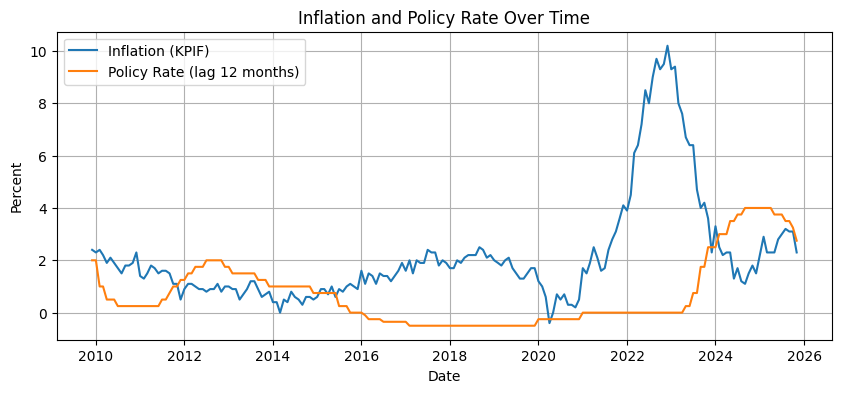

In [27]:
plt.figure(figsize=(10,4))
plt.plot(df_lag['date'], df_lag['inflation'], label='Inflation (KPIF)')
plt.plot(df_lag['date'], df_lag['styrränta_lag12'], label='Policy Rate (lag 12 months)')
plt.xlabel('Date')
plt.ylabel('Percent')
plt.title('Inflation and Policy Rate Over Time')
plt.legend()
plt.grid(True)
plt.show()

Finally, we examine the correlation between inflation and lagged policy rates. The correlation decreases as the lag increases and turns negative at longer horizons, suggesting a delayed dampening effect of monetary policy. However, at very long lags, such as 48 months, the strong negative correlation is more likely to reflect long-run macroeconomic cycles and regime shifts rather than a direct causal effect of monetary policy.

In [24]:
#cols = ['styrränta', 'styrränta_lag1', 'styrränta_lag3', 'styrränta_lag6', 'styrränta_lag-1']
cols = ['styrränta', 'styrränta_lag1', 'styrränta_lag3', 'styrränta_lag6', 'styrränta_lag12','styrränta_lag24', 'styrränta_lag48']
print(df_lag[['inflation'] + cols].corr())


                 inflation  styrränta  styrränta_lag1  styrränta_lag3  \
inflation         1.000000   0.329747        0.279126        0.179948   
styrränta         0.329747   1.000000        0.993500        0.973036   
styrränta_lag1    0.279126   0.993500        1.000000        0.986315   
styrränta_lag3    0.179948   0.973036        0.986315        1.000000   
styrränta_lag6    0.051079   0.911617        0.935061        0.972910   
styrränta_lag12  -0.092608   0.712546        0.747616        0.814353   
styrränta_lag24  -0.134161   0.188602        0.203276        0.237372   
styrränta_lag48  -0.352882  -0.002249        0.005689        0.019659   

                 styrränta_lag6  styrränta_lag12  styrränta_lag24  \
inflation              0.051079        -0.092608        -0.134161   
styrränta              0.911617         0.712546         0.188602   
styrränta_lag1         0.935061         0.747616         0.203276   
styrränta_lag3         0.972910         0.814353         0.237372 

# 3. Model Building and Evalutation

---

Given a continuous dependent variable and the exploratory indication of lag-dependent relationships, we employ linear regression models with lagged policy rates to quantify the association between monetary policy and inflation. <br>
<br>

In [29]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

### Model A:  i_t = β_0 ​+ β_1​r_(t−24) ​+ ε_t​

---
=> Can inflation today be explained by policy rate two years ago?

In [31]:
# The first model (i_t​ = β_0 ​+ β_1​r_(t−24) ​+ ε_t​) => Can inflation today be explained by policy rate two years ago?

X_A = df_lag[['styrränta_lag24']]
y = df_lag['inflation']

model_A = LinearRegression().fit(X_A, y)
y_pred_A = model_A.predict(X_A)

print("Model A")
print("Coefficient (β_1):", model_A.coef_[0])
print("Intercept (β_0):", model_A.intercept_)
print("R²:", r2_score(y, y_pred_A))
print("MSE:", mean_squared_error(y, y_pred_A))


Model A
Coefficient (β_1): -0.20229134408024255
Intercept (β_0): 2.33398136285683
R²: 0.017999121075438995
MSE: 4.221605369193807


The model give a low R², which suggest limited explanatory power. This could be reasonable given the multifactor nature of inflation. Since the analysis is not focused on prediction, the mean squared error is not a central evaluation metric.

In [33]:
results = pd.DataFrame({
    'Model': ['lag 24 months'],
    'R2': [r2_score(y, y_pred_A)],
    'MSE': [mean_squared_error(y, y_pred_A)]
})

print(results)


           Model        R2       MSE
0  lag 24 months  0.017999  4.221605


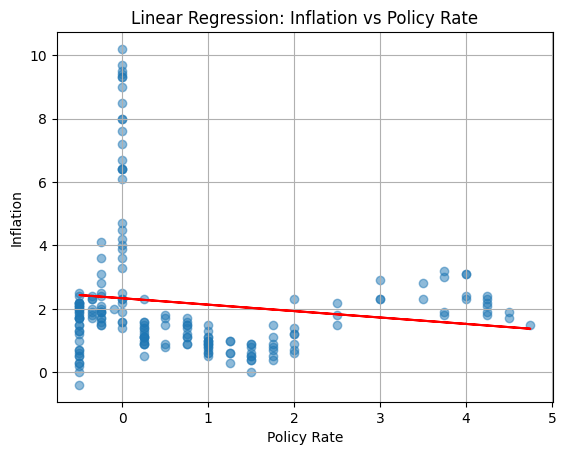

In [36]:
import matplotlib.pyplot as plt
import numpy as np

x = df_lag['styrränta_lag24']
y_line = model_A.intercept_ + model_A.coef_[0] * x

plt.scatter(x, y, alpha=0.5)
plt.plot(x, y_line, color='red')
plt.xlabel('Policy Rate')
plt.ylabel('Inflation')
plt.title('Linear Regression: Inflation vs Policy Rate')
plt.grid(True)
plt.show()


### Model B: Multiple time lags
---
i_t = β_0 + β_1·r_(t-3) + β_2·r_(t-12) + β_3·r_(t-24) + ε_t

In [35]:
X_B = df_lag[['styrränta_lag3', 'styrränta_lag12','styrränta_lag24']]
model_B = LinearRegression().fit(X_B, y)
y_pred_B = model_B.predict(X_B)

print("Model B")
print("Coefficient:", model_B.coef_)
print("Intercept:", model_B.intercept_)
print("R²:", r2_score(y, y_pred_B))
print("MSE:", mean_squared_error(y, y_pred_B))

Model B
Coefficient: [ 1.2937917  -1.330227    0.17713586]
Intercept: 1.9894738339837683
R²: 0.2102859550868854
MSE: 3.3949674829049488


A suspisiously high increase in R2-score is observed for model B. Policy rates are strongly autocorrelated. So a check for multicolliniarity before interpretation is necessary. Generally, a VIF between 1 and 3 is considered low, between 3 and 5 moderate, and 5 or above high [3].

[3]. https://www.investopedia.com/terms/v/variance-inflation-factor.asp

In [37]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df_lag[['styrränta_lag3', 'styrränta_lag12', 'styrränta_lag24']]
X = X.dropna()

vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Variable,VIF
0,styrränta_lag3,4.360538
1,styrränta_lag12,6.161378
2,styrränta_lag24,1.953190


A high VIF is seen particularly for the 12 month time lag (which is natural). Hence, coefficients are carefully interpreted. The variable with the highest multicollinarity is therefor dropped, creating a new model C.

### Model C: β_0 + β_1·r_(t-3) + β_2·r_(t-24) + ε_t

----
Model C captures short and long term reactions.

In [38]:
X_C = df_lag[['styrränta_lag3', 'styrränta_lag24']]
model_C = LinearRegression().fit(X_C, y)

In [39]:
y_pred_C = model_C.predict(X_C)

print("Model C")
print("Coefficient:", model_C.coef_)
print("Intercept:", model_C.intercept_)
print("R²:", r2_score(y, y_pred_C))
print("MSE:", mean_squared_error(y, y_pred_C))

Model C
Coefficient: [ 0.35043657 -0.28262228]
Intercept: 2.118164030597841
R²: 0.06553426474718993
MSE: 4.017252580864501


Before interpretation a look at multicolinearity,

In [40]:
X = df_lag[['styrränta_lag3', 'styrränta_lag24']]
X = X.dropna()

vif = pd.DataFrame()
vif['Variable'] = X.columns
vif['VIF'] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
vif

,Variable,VIF
0,styrränta_lag3,1.2216
1,styrränta_lag24,1.2216


VIF values are fine, indicating low correlation between independent variables of the model. Regarding the performance of the model the R2 score increase about three times compared to A, making it the best model. About 6-7 % of variation in inflation can be explained by the model. This is not a particularly strong explanatory power. Although a low R2 score might be expected for macrodata.

### A final comment:

The results indicate a weak but negative relationship between lagged policy rates and inflation, with the strongest association observed at longer lags. This is consistent with the delayed transmission of monetary policy.

# 4. Dashboard and Visualisation
---

In [41]:
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pandas as pd
import numpy as np


In [42]:
fig_ts = go.Figure()

fig_ts.add_trace(go.Scatter(
    x=df_lag.index,
    y=df_lag['inflation'],
    mode='lines',
    name='Inflation'
))

fig_ts.add_trace(go.Scatter(
    x=df_lag.index,
    y=df_lag['styrränta'],
    mode='lines',
    name='Policy Rate',
    yaxis='y2'
))

fig_ts.update_layout(
    title='Inflation and Policy Rate Over Time',
    yaxis=dict(title='Inflation'),
    yaxis2=dict(title='Policy Rate', overlaying='y', side='right'),
    legend=dict(x=0.01, y=0.99)
)


In [44]:
lags = [0, 3, 6, 12, 24]
correlations = [
    df_lag['inflation'].corr(df_lag[f'styrränta_lag{lag}']) if lag > 0
    else df_lag['inflation'].corr(df_lag['styrränta'])
    for lag in lags
]

fig_corr = go.Figure()

fig_corr.add_trace(go.Scatter(
    x=lags,
    y=correlations,
    mode='lines+markers'
))

fig_corr.update_layout(
    title='Correlation Between Inflation and Lagged Policy Rate',
    xaxis_title='Lag (months)',
    yaxis_title='Correlation'
)


In [45]:
x = df_lag['styrränta_lag24']
y = df_lag['inflation']

y_line = model_C.intercept_ + model_C.coef_[1] * x  # coef_[1] = lag24

fig_reg = go.Figure()

fig_reg.add_trace(go.Scatter(
    x=x,
    y=y,
    mode='markers',
    name='Data',
    opacity=0.5
))

fig_reg.add_trace(go.Scatter(
    x=x,
    y=y_line,
    mode='lines',
    name='Regression Line'
))

fig_reg.update_layout(
    title='Inflation vs Policy Rate (24-month lag)',
    xaxis_title='Policy Rate (lag 24)',
    yaxis_title='Inflation'
)


In [50]:
results_df = pd.DataFrame({
    'Metric': ['Intercept', 'Coeff (lag 3 months)', 'Coeff (lag 24 months)', 'R²', 'MSE'],
    'Value': [
        round(model_C.intercept_, 3),
        round(model_C.coef_[0], 3),
        round(model_C.coef_[1], 3),
        round(r2_score(y, model_C.predict(df_lag[['styrränta_lag3','styrränta_lag24']])), 3),
        round(mean_squared_error(y, model_C.predict(df_lag[['styrränta_lag3','styrränta_lag24']])), 2)
    ]
})


fig_table = go.Figure(data=[go.Table(
    header=dict(values=list(results_df.columns)),
    cells=dict(values=[results_df[col] for col in results_df.columns])
)])

fig_table.update_layout(title='Model C – Regression Results')



In [51]:
from plotly.subplots import make_subplots

# Gör fyra subplots
dashboard = make_subplots(
    rows=3, cols=2,
    specs=[
        [{"colspan": 2}, None],
        [{"colspan": 2}, None],
        [{"type": "xy"}, {"type": "domain"}]  # viktigt: domain för table
    ],
    subplot_titles=[
        "Time Series",
        "Correlation vs Lag",
        "Regression (lag 24)",
        "Model Results"
    ]
)

# Lägg till
for trace in fig_ts.data:
    dashboard.add_trace(trace, row=1, col=1)

for trace in fig_corr.data:
    dashboard.add_trace(trace, row=2, col=1)

for trace in fig_reg.data:
    dashboard.add_trace(trace, row=3, col=1)

for trace in fig_table.data:
    dashboard.add_trace(trace, row=3, col=2)

# Lite layout

dashboard.update_layout(height=900, title_text="Monetary Policy and Inflation – Interactive Analysis")
dashboard.update_xaxes(title_text="Time", row=1, col=1)
dashboard.update_yaxes(title_text="Inflation", row=1, col=1)
dashboard.update_yaxes(title_text="Policy Rate", row=1, col=1, secondary_y=True)

dashboard.update_xaxes(title_text="Lag (months)", row=2, col=1)
dashboard.update_yaxes(title_text="Correlation", row=2, col=1)

dashboard.update_xaxes(title_text="Policy Rate (lag 24 months)", row=3, col=1)
dashboard.update_yaxes(title_text="Inflation", row=3, col=1)


In [53]:
#Skapa HTML

filename = "inflation_policy_dashboard.html"
dashboard.write_html(filename)

from google.colab import files
files.download(filename)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>